In [ ]:
# Cell 1: Imports + SEED Setup

import os
import random
import numpy as np

# Fix all randomness
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
# TensorFlow seed will be applied after importing tf

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras import layers, Model




In [ ]:
# Cell 2: Load dataset
df = pd.read_csv("/bank.csv")

print(df.head())
print(df.info())
print(df.isna().sum())


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

In [ ]:
# Cell 3: Clean target variable
df["deposit"] = df["deposit"].map({"yes":1, "no":0})

# Drop rows with missing target
df = df.dropna(subset=["deposit"])
df.shape


(11162, 17)

In [ ]:
# Cell 4: Detect feature types
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

# Remove target from numeric list
if "deposit" in numeric_cols:
    numeric_cols.remove("deposit")
# Remove duration to avoid data leakage
if "duration" in numeric_cols:
    numeric_cols.remove("duration")

categorical_cols, numeric_cols


(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'],
 ['age', 'balance', 'day', 'campaign', 'pdays', 'previous'])

In [ ]:
df_eda = df.copy()


In [ ]:
for col in categorical_cols:
    df_eda[col] = df_eda.groupby(col)['deposit'].transform('mean')




In [ ]:
corr = df_eda.corr()


Correlation Matrix:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
age,1.000000,0.200074,-0.424931,-0.147426,0.011425,0.112300,0.168700,0.031418,0.021707,-0.000762,0.108989,0.000189,-0.005278,0.002774,0.020169,0.055814,0.034901
job,0.200074,1.000000,0.111165,0.213819,0.030692,0.073239,0.273225,0.114597,0.167819,0.000402,0.211868,-0.016303,-0.042921,0.044809,0.061901,0.135022,0.184042
marital,-0.424931,0.111165,1.000000,0.151981,0.000442,-0.020822,0.042866,0.059166,0.047577,-0.003662,0.031628,0.031098,-0.049644,0.027461,0.016413,0.026179,0.099083
education,-0.147426,0.213819,0.151981,1.000000,0.013448,0.061822,0.115124,0.070989,0.143251,0.014172,0.109420,-0.014127,-0.008446,0.023692,0.029530,0.078794,0.104876
default,0.011425,0.030692,0.000442,0.013448,1.000000,0.060954,0.011076,0.076434,0.041397,-0.017342,0.044025,0.009760,-0.030975,0.036282,0.035273,0.049196,0.040680
balance,0.112300,0.073239,-0.020822,0.061822,0.060954,1.000000,0.077092,0.084589,0.041898,0.010467,0.077174,0.022436,-0.013894,0.017411,0.030805,0.052478,0.081129
housing,0.168700,0.273225,0.042866,0.115124,0.011076,0.077092,1.000000,0.076761,0.250162,0.014770,0.285616,-0.035051,-0.006660,-0.064497,0.000840,0.115669,0.203888
loan,0.031418,0.114597,0.059166,0.070989,0.076434,0.084589,0.076761,1.000000,0.011670,-0.017269,0.091448,0.001914,-0.034722,0.030416,0.022668,0.083523,0.110580
contact,0.021707,0.167819,0.047577,0.143251,0.041397,0.041898,0.250162,0.011670,1.000000,-0.004574,0.309017,0.014457,-0.049010,0.232268,0.178318,0.224915,0.256904
day,-0.000762,0.000402,-0.003662,0.014172,-0.017342,0.010467,0.014770,-0.017269,-0.004574,1.000000,-0.047539,-0.018511,0.137007,-0.077232,-0.058981,-0.059665,-0.056326


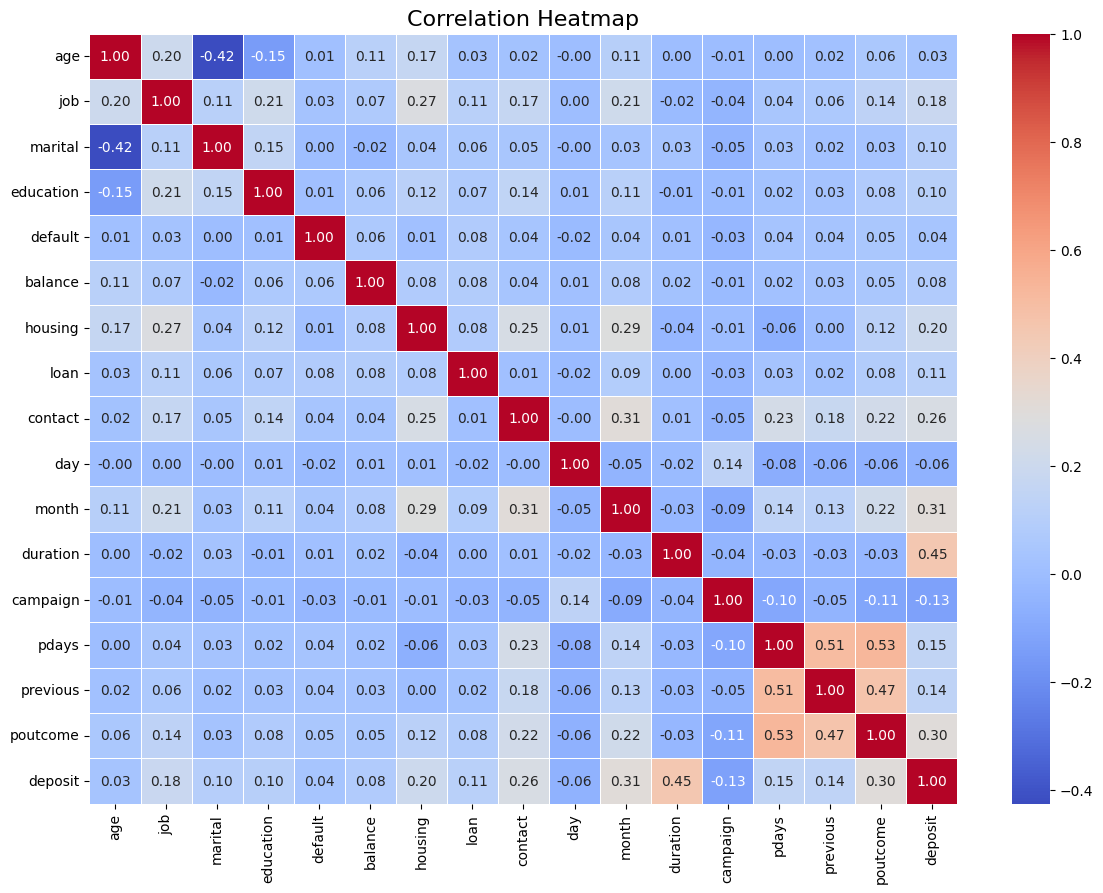

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print("Correlation Matrix:")
display(corr)

# correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [ ]:
# Label-encode categorical features
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


/tmp/ipython-input-382832573.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Purples")


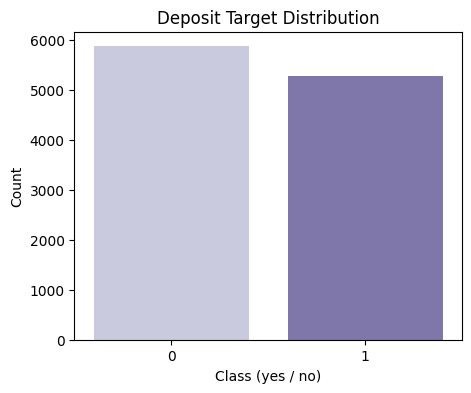

In [ ]:
# Cell: Simple EDA

import matplotlib.pyplot as plt
import seaborn as sns

target_col = "deposit"

#  Target distribution(Balanced / Imbalanced?)
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df, palette="Purples")
plt.title("Deposit Target Distribution")
plt.xlabel("Class (yes / no)")
plt.ylabel("Count")
plt.show()



In [ ]:
# Split data
X = df[categorical_cols + numeric_cols]
y = df["deposit"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape


((7813, 15), (1674, 15), (1675, 15))

In [ ]:
# Scale numeric features only
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_val_num = scaler.transform(X_val[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

# Convert categorical to numpy int32 for embeddings
X_train_cat = X_train[categorical_cols].astype("int32")
X_val_cat = X_val[categorical_cols].astype("int32")
X_test_cat = X_test[categorical_cols].astype("int32")


In [ ]:
print(X_train_num.shape)
print(X_train_num[:5, :])


(7813, 6)
[[ 1.50785016 -0.49891274  1.57182714 -0.17694985 -0.48185906 -0.35547749]
 [-0.85119791 -0.3465419   1.69040892 -0.53354236 -0.48185906 -0.35547749]
 [-0.59844276  0.92880876  0.62317285 -0.53354236 -0.48185906 -0.35547749]
 [-0.68269447 -0.39722031 -1.51129928 -0.53354236  2.30324192  1.78127097]
 [-0.26143589 -0.49891274  1.33466357 -0.53354236  0.21902728  0.92657159]]


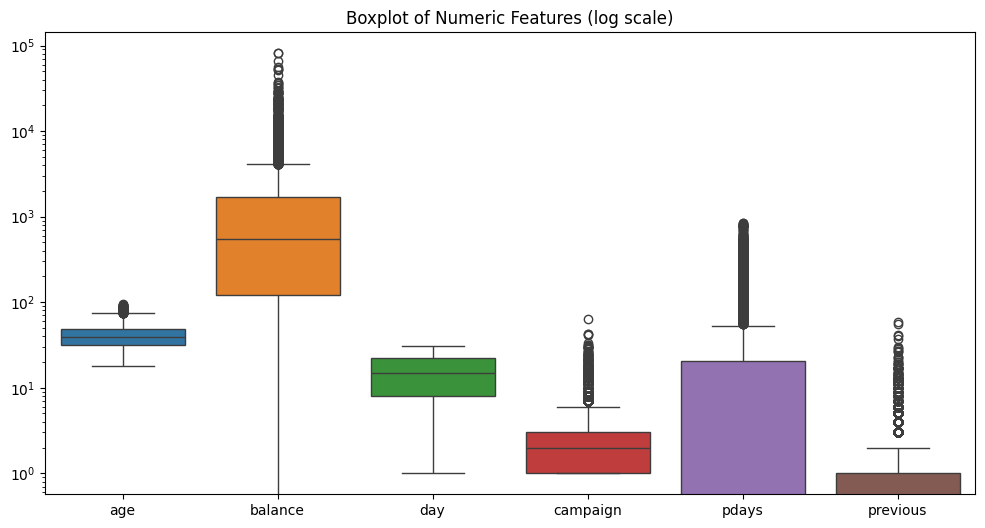

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.yscale('log')
plt.title("Boxplot of Numeric Features (log scale)")
plt.show()


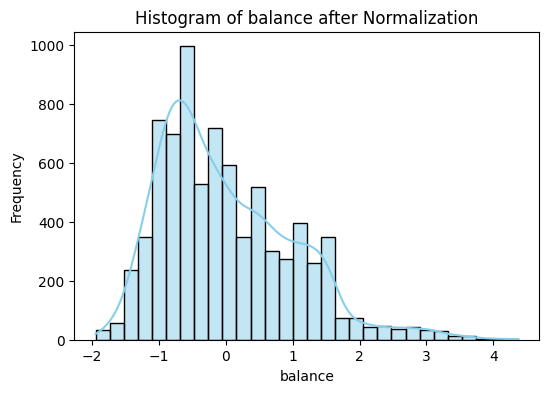

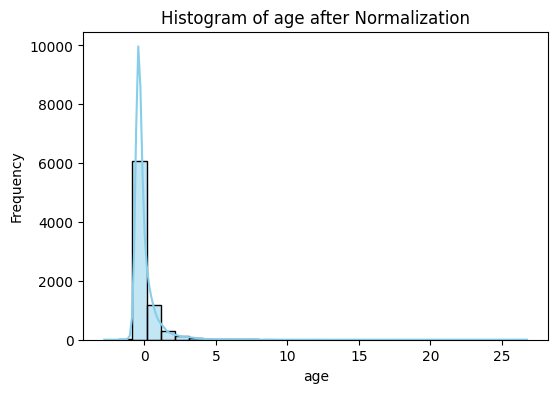

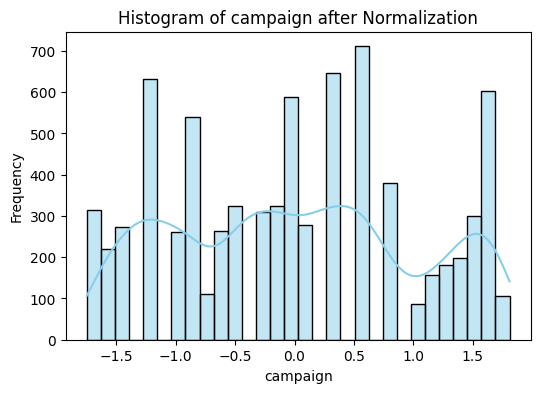

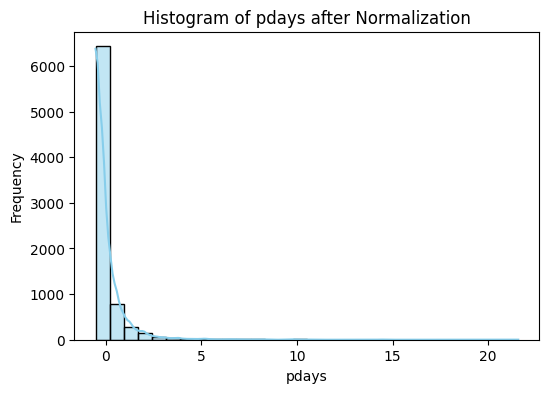

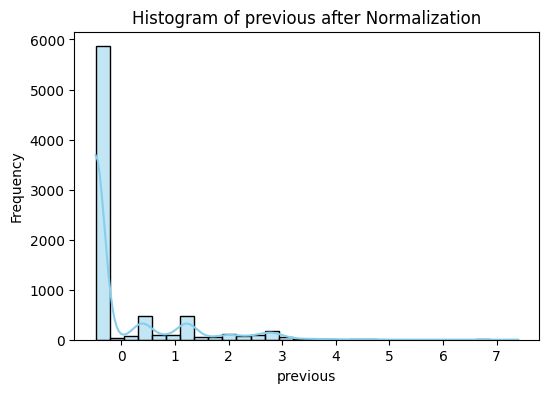

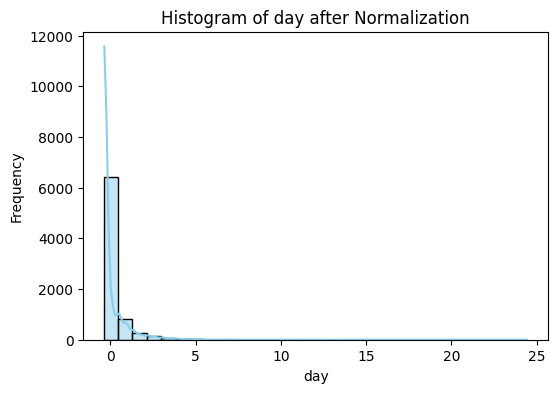

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric columns
numeric_cols = ['balance', 'age',  'campaign', 'pdays', 'previous','day']

#Normalization
X_scaled = pd.DataFrame(X_train_num, columns=numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_scaled[col], bins=30, kde=True, color='skyblue')
    plt.title(f"Histogram of {col} after Normalization")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Value counts for job:
job_name
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64 

Value counts for marital:
marital_name
married     6351
divorced    3518
single      1293
Name: count, dtype: int64 

Value counts for education:
education_name
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64 

Value counts for default:
default_name
no     10994
yes      168
Name: count, dtype: int64 

Value counts for housing:
housing_name
no     5881
yes    5281
Name: count, dtype: int64 

Value counts for loan:
loan_name
no     9702
yes    1460
Name: count, dtype: int64 

Value counts for contact:
contact_name
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64 

Value counts for month:
mo

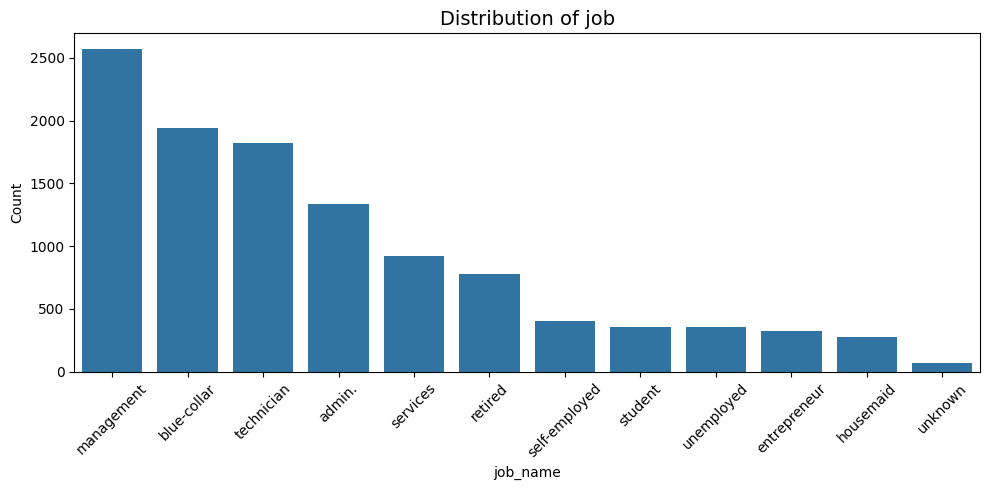

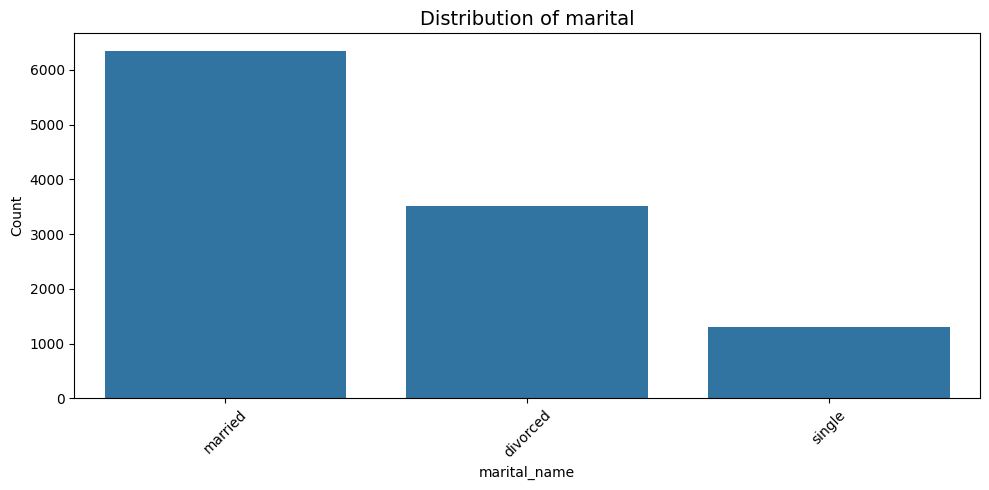

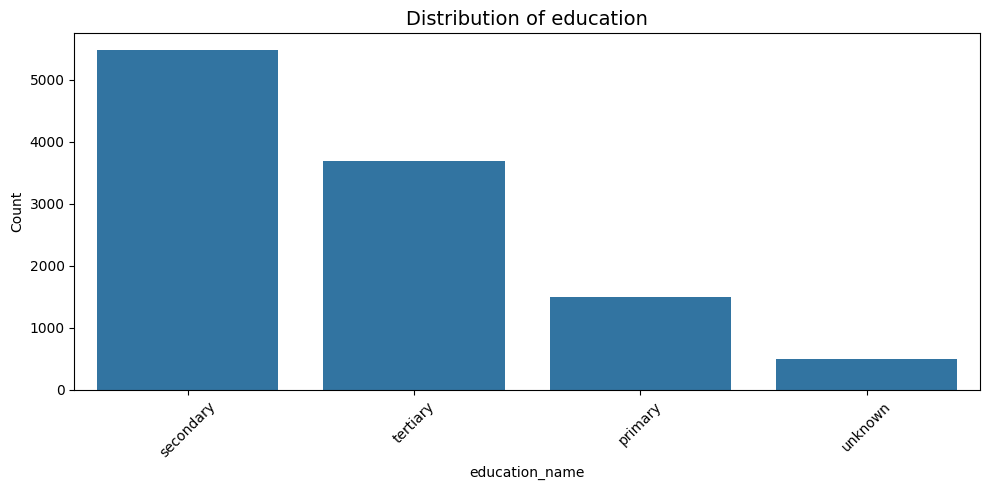

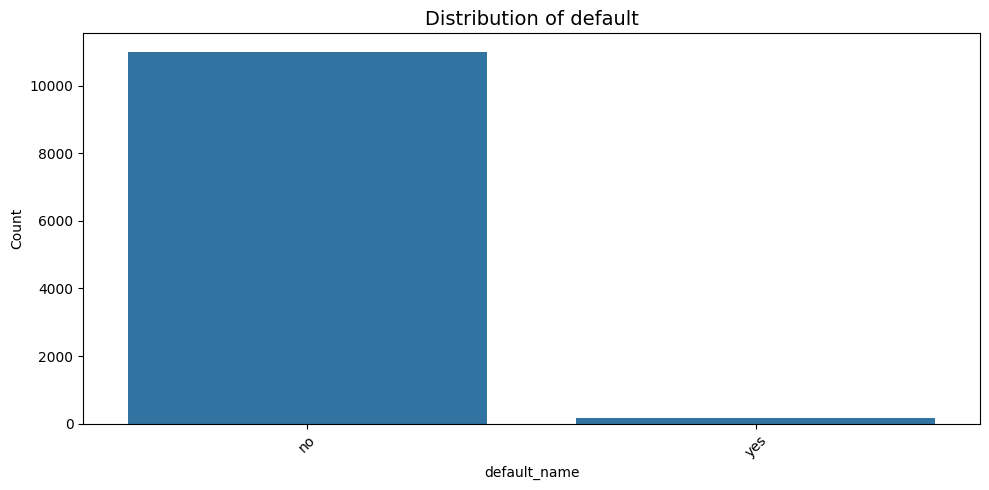

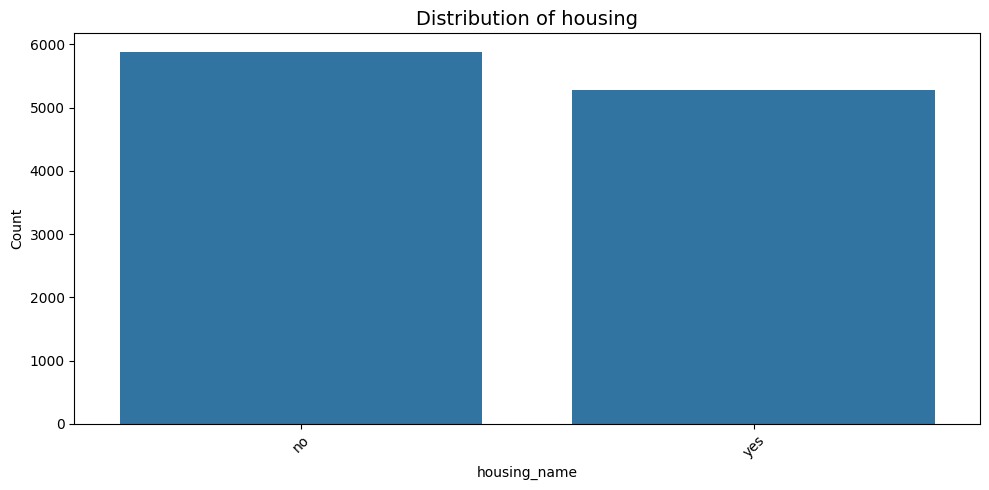

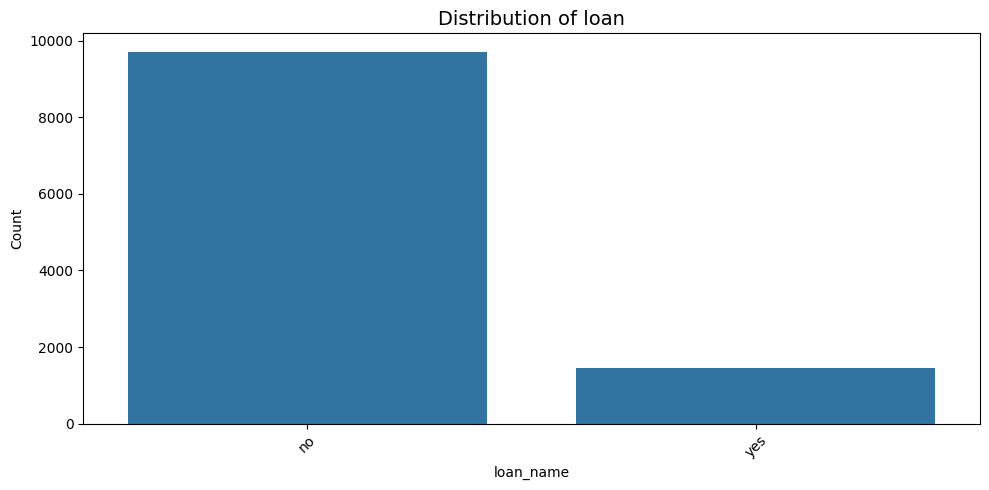

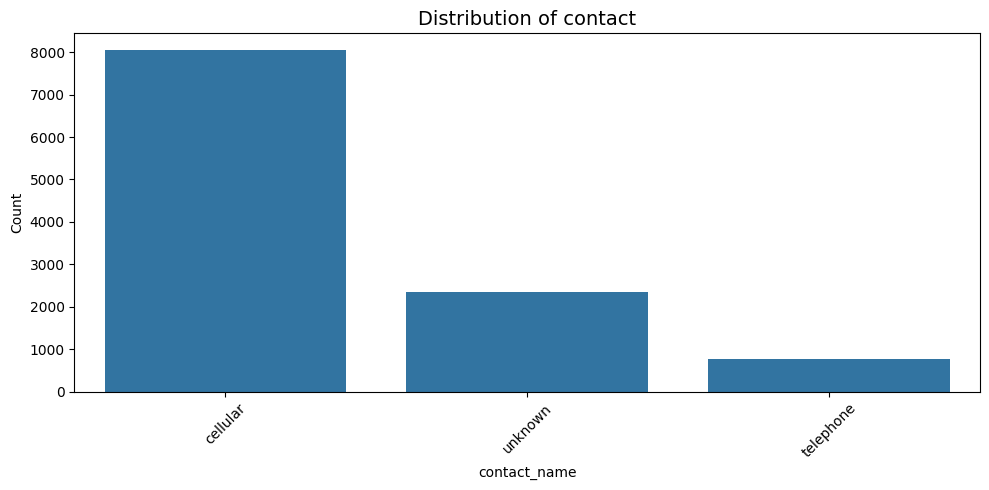

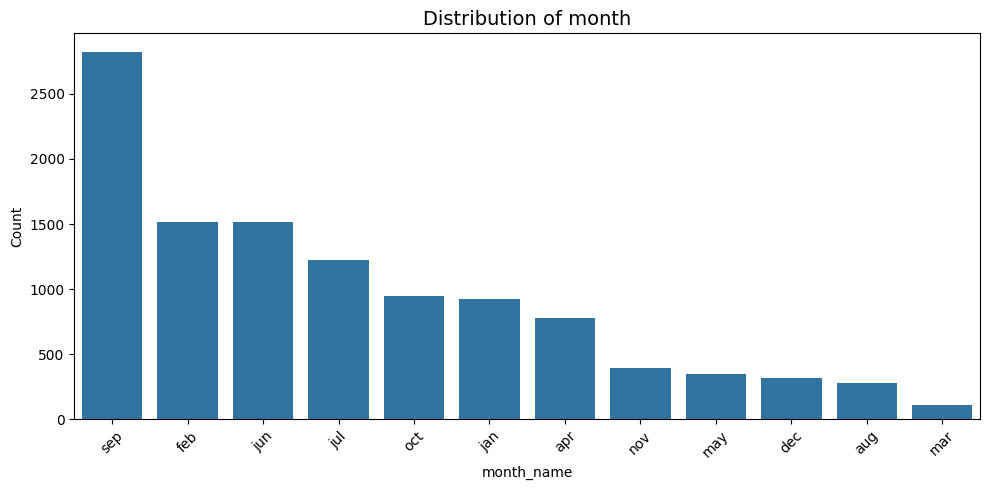

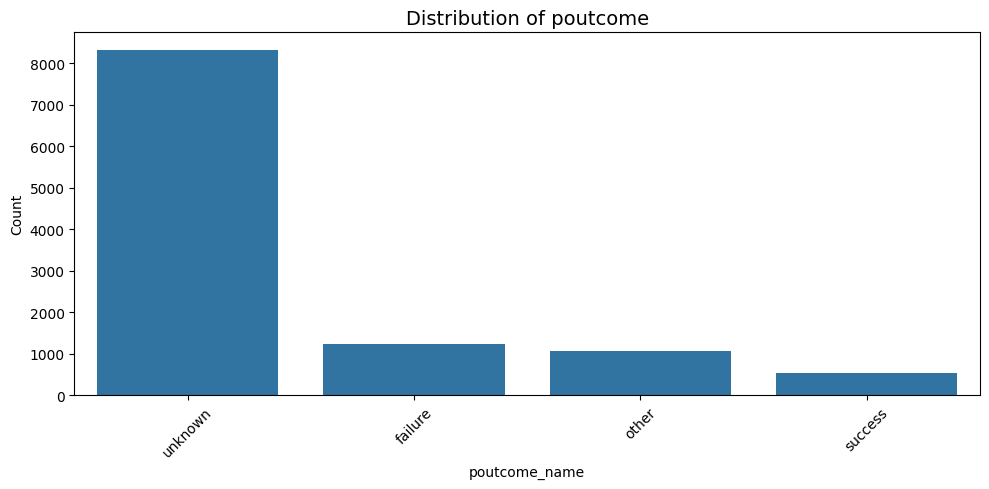

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# category columns.
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

#set mappings for each column (category names).
mappings = {
    'job': { 0: "admin.",1: "blue-collar", 2: "entrepreneur",  3: "housemaid",4: "management",5: "retired",6: "self-employed",7: "services",8: "student",9: "technician",10: "unemployed",11: "unknown"
    },
    'marital': {0:"single",1:"married",2:"divorced"},
    'education': {0:"primary",1:"secondary",2:"tertiary",3:"unknown"},
    'default': {0:"no",1:"yes"},
    'housing': {0:"no",1:"yes"},
    'loan': {0:"no",1:"yes"},
    'contact': {0:"cellular",1:"telephone",2:"unknown"},
    'month': {0:"jan",1:"feb",2:"mar",3:"apr",4:"may",5:"jun",6:"jul",7:"aug",8:"sep",9:"oct",10:"nov",11:"dec"},
    'poutcome': {0:"failure",1:"success",2:"other",3:"unknown"}
}

for col in categorical_cols:
    df[col + "_name"] = df[col].map(mappings[col])
    print(f"Value counts for {col}:")
    print(df[col + "_name"].value_counts(), "\n")

 #Draw ALL category column.
for col in categorical_cols:
    df[col + "_name"] = df[col].map(mappings[col])

    plt.figure(figsize=(10,5))
    sns.countplot(x=col + "_name", data=df, order=df[col + "_name"].value_counts().index)
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [ ]:
#  Build TabTransformer without Stack

def transformer_block(x, head, dim, ff_dim):
    attn = layers.MultiHeadAttention(num_heads=head, key_dim=dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # FNN
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    return x



def build_tabtransformer(
    num_numeric,
    num_categories,
    vocab_sizes,
    dim=32,
    heads=4,
    blocks=2,
    ff_dim=128,
):

    # Numeric features input
    numeric_in = layers.Input(shape=(num_numeric,), name="numeric_inputs")

    # Embeddings for categorical
    cat_inputs = []
    cat_embeds = []

    for i, vocab in enumerate(vocab_sizes):
        inp = layers.Input(shape=(1,), name=f"cat{i}")
        emb = layers.Embedding(input_dim=vocab, output_dim=dim)(inp)
        emb = layers.Reshape((dim,))(emb)
        cat_inputs.append(inp)
        cat_embeds.append(emb)

    # Stack embeddings as tokens: (batch, num_categories, dim)
    x = layers.Lambda(lambda t: tf.stack(t, axis=1))(cat_embeds)

    # Transformer blocks using ff_dim
    for _ in range(blocks):
        x = transformer_block(x, heads, dim, ff_dim)

    # Flatten tokens
    x = layers.Flatten()(x)

    # Concatenate with numeric
    combined = layers.Concatenate()([x, numeric_in])

    # MLP head
    out = layers.Dense(64, activation="relu")(combined)
    out = layers.Dense(32, activation="relu")(out)
    out = layers.Dense(1, activation="sigmoid")(out)

    return Model(inputs=[numeric_in] + cat_inputs, outputs=out)



Epoch 1/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.6401 - loss: 0.6261 - val_accuracy: 0.6876 - val_loss: 0.5873 - learning_rate: 0.0010
Epoch 2/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7017 - loss: 0.5786 - val_accuracy: 0.6900 - val_loss: 0.5803 - learning_rate: 0.0010
Epoch 3/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7078 - loss: 0.5704 - val_accuracy: 0.6912 - val_loss: 0.5793 - learning_rate: 0.0010
Epoch 4/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7096 - loss: 0.5655 - val_accuracy: 0.7007 - val_loss: 0.5667 - learning_rate: 0.0010
Epoch 5/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7135 - loss: 0.5623 - val_accuracy: 0.7079 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 6/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7204 - loss: 0.5592 - val_accuracy: 0.7073 - val_loss: 0.5707 - learning_rate: 0.0010
Epoch 7/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7244 - loss: 0

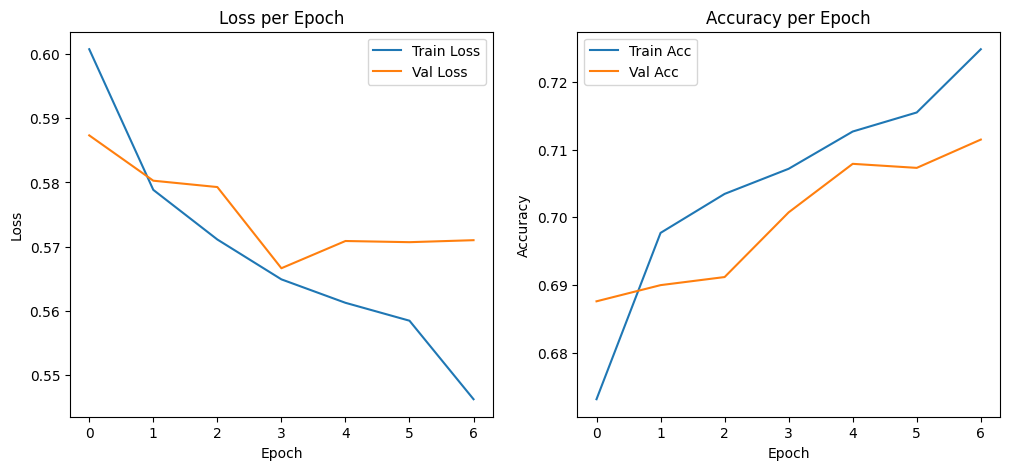

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Setting up callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)
# Setting up vocab_sizes for each categorical column

vocab_sizes = [df[col].nunique() + 1 for col in categorical_cols]

# Building the model
model = build_tabtransformer(
    num_numeric=len(numeric_cols),
    num_categories=len(categorical_cols),
    vocab_sizes=vocab_sizes,
    dim=32,
    heads=4,
    blocks=2,
    ff_dim=128,
)


model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
# Preparing the inputs
train_inputs = {"numeric_inputs": X_train_num}
val_inputs = {"numeric_inputs": X_val_num}
test_inputs = {"numeric_inputs": X_test_num}

for i, col in enumerate(categorical_cols):
    train_inputs[f"cat{i}"] = X_train_cat[col]
    val_inputs[f"cat{i}"] = X_val_cat[col]
    test_inputs[f"cat{i}"] = X_test_cat[col]

# Training the model

history = model.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, lr_reducer]
)

# Model probabilities before tuning on the test set
y_pred_proba_default = model.predict(test_inputs).flatten()



# Plotting Loss and Accuracy for each epoch
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import average_precision_score, roc_curve, roc_auc_score

ap_default = average_precision_score(y_test, y_pred_proba_default)
print("AP (Default TabTransformer):", ap_default)



AP (Default TabTransformer): 0.762617356833714


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_default, tpr_default, thresholds_default = roc_curve(y_test, y_pred_proba_default)
roc_auc_default = roc_auc_score(y_test, y_pred_proba_default)

print("ROC-AUC (Default TabTransformer):", roc_auc_default)



ROC-AUC (Default TabTransformer): 0.7674599793570965


Accuracy (Default TabTransformer): 0.6997014925373134
Classification Report (Default TabTransformer):
              precision    recall  f1-score   support

           0     0.6944    0.7662    0.7285       881
           1     0.7070    0.6259    0.6640       794

    accuracy                         0.6997      1675
   macro avg     0.7007    0.6961    0.6963      1675
weighted avg     0.7004    0.6997    0.6979      1675



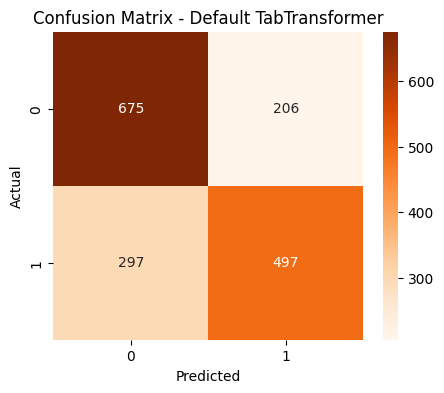

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Converting probabilities to 0/1 class labels
y_pred_default = (y_pred_proba_default > 0.5).astype(int)

print("Accuracy (Default TabTransformer):", accuracy_score(y_test, y_pred_default))
print("Classification Report (Default TabTransformer):")
print(classification_report(y_test, y_pred_default, digits=4))

cm_default = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(5,4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - Default TabTransformer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


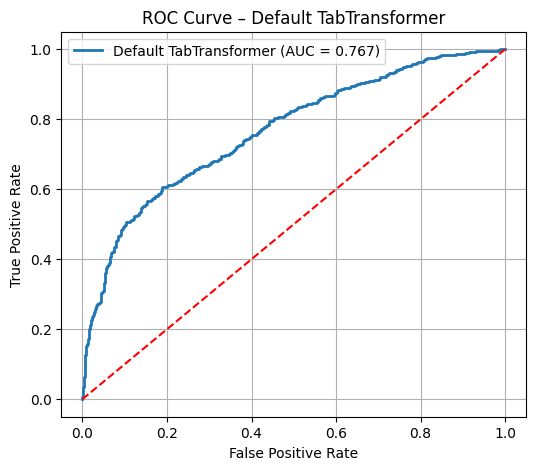

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr_default, tpr_default, label=f'Default TabTransformer (AUC = {roc_auc_default:.3f})', linewidth=2)

# A random line for comparison
plt.plot([0, 1], [0, 1],color='red',linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Default TabTransformer')
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
import random
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fixed callbacks for all experiments

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

configs = []
results = []

num_trials = 6

for trial in range(num_trials):

    cfg = {
        "d_model": random.choice([16, 32, 64]),
        "num_heads": random.choice([2, 4, 8]),
        "ff_dim": random.choice([32, 64, 128]),
        "num_blocks": random.choice([1, 2, 3])
    }

    print(f"\nTrial {trial+1} - Testing config: {cfg}")
    configs.append(cfg)

    # Building the model
    model_tune = build_tabtransformer(
        num_numeric=len(numeric_cols),
        num_categories=len(categorical_cols),
        vocab_sizes=vocab_sizes,
        dim=cfg["d_model"],
        heads=cfg["num_heads"],
        blocks=cfg["num_blocks"],
        ff_dim=cfg["ff_dim"],
    )

    model_tune.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

# Training the model
    history_tune = model_tune.fit(
        train_inputs, y_train,
        validation_data=(val_inputs, y_val),
        epochs=15,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop, lr_reducer]
    )

    # Best accuracy on the validation set
    best_val_acc = max(history_tune.history["val_accuracy"])
    print(f"Best val accuracy: {best_val_acc:.4f}")
    results.append(best_val_acc)

#Best configuration after all experiments
best_config = configs[results.index(max(results))]
print("\n====================")
print("BEST CONFIG FOUND:")
print(best_config)
print("====================")



Trial 1 - Testing config: {'d_model': 16, 'num_heads': 8, 'ff_dim': 128, 'num_blocks': 3}
Epoch 1/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.6625 - loss: 0.6189 - val_accuracy: 0.6828 - val_loss: 0.5858 - learning_rate: 0.0010
Epoch 2/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7029 - loss: 0.5737 - val_accuracy: 0.6762 - val_loss: 0.5852 - learning_rate: 0.0010
Epoch 3/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.7100 - loss: 0.5660 - val_accuracy: 0.6906 - val_loss: 0.5729 - learning_rate: 0.0010
Epoch 4/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7144 - loss: 0.5604 - val_accuracy: 0.7007 - val_loss: 0.5723 - learning_rate: 0.0010
Epoch 5/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7180 - loss: 0.5553 - val_accuracy: 0.7091 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 6/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7328 - loss: 0.5427 - val_accuracy: 0.7115 - val_loss: 0.5625 - learning_ra

Epoch 1/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6549 - loss: 0.6146 - val_accuracy: 0.6930 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 2/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7114 - loss: 0.5712 - val_accuracy: 0.6959 - val_loss: 0.5775 - learning_rate: 0.0010
Epoch 3/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7158 - loss: 0.5660 - val_accuracy: 0.7007 - val_loss: 0.5684 - learning_rate: 0.0010
Epoch 4/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7180 - loss: 0.5601 - val_accuracy: 0.7085 - val_loss: 0.5649 - learning_rate: 0.0010
Epoch 5/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7205 - loss: 0.5566 - val_accuracy: 0.7079 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 6/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7230 - loss: 0.5514 - val_accuracy: 0.7049 - val_loss: 0.5641 - learning_rate: 0.0010
Epoch 7/15
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7281 - loss: 0

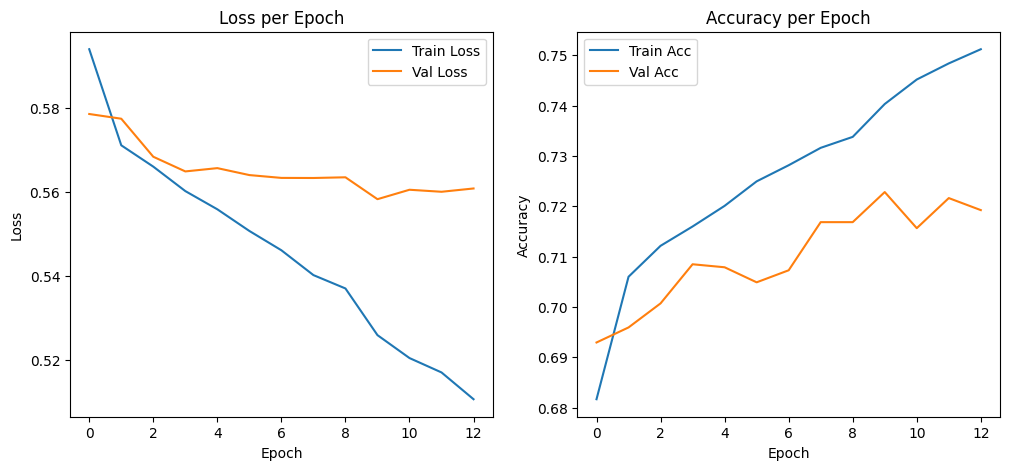

In [ ]:
# ============================
# Final TabTransformer Model Training & Evaluation
# ============================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

final_model = build_tabtransformer(
    num_numeric=len(numeric_cols),
    num_categories=len(categorical_cols),
    vocab_sizes=vocab_sizes,
    dim=best_config["d_model"],
    heads=best_config["num_heads"],
    blocks=best_config["num_blocks"],
    ff_dim=best_config["ff_dim"]
)

final_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# --- Preparing the inputs ---
train_inputs = {"numeric_inputs": X_train_num}
val_inputs = {"numeric_inputs": X_val_num}
test_inputs = {"numeric_inputs": X_test_num}

for i, col in enumerate(categorical_cols):
    train_inputs[f"cat{i}"] = X_train_cat[col]
    val_inputs[f"cat{i}"] = X_val_cat[col]
    test_inputs[f"cat{i}"] = X_test_cat[col]

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)

#--- Training the final model ---
history_final = final_model.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=15,  # EarlyStopping stops training when validation stops improving
    batch_size=32,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

# --- Evaluating the model on the test set ---
test_loss, test_acc = final_model.evaluate(test_inputs, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# --- Plotting the training performance ---
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_final.history['accuracy'], label='Train Acc')
plt.plot(history_final.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy: 0.7122388059701492
Classification Report:

              precision    recall  f1-score   support

           0     0.6962    0.8036    0.7460       881
           1     0.7371    0.6108    0.6680       794

    accuracy                         0.7122      1675
   macro avg     0.7166    0.7072    0.7070      1675
weighted avg     0.7156    0.7122    0.7091      1675



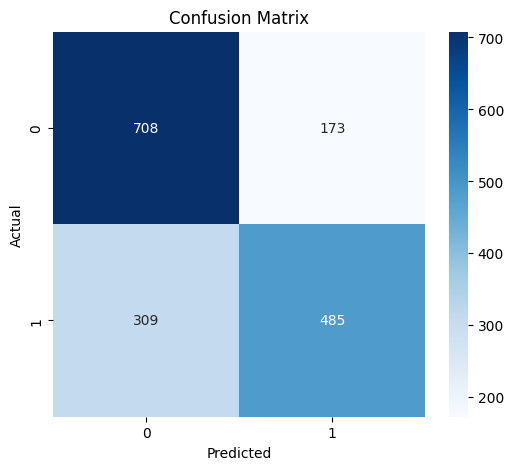

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Model prediction on the test set ---
y_pred_probs = final_model.predict(test_inputs)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  #Converting probabilities into 0/1 classes

print("Accuracy:", accuracy_score(y_test, y_pred))
# --- Classification Report ---
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


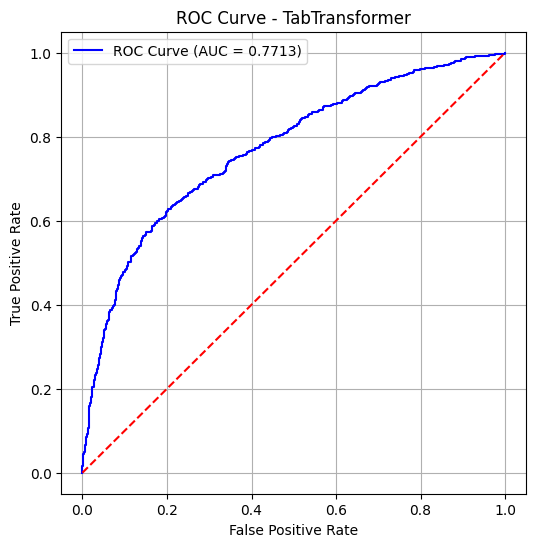

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- Predicting probabilities on the test set ---
y_pred_probs = final_model.predict(test_inputs).flatten()

# --- Calculating the False Positive Rate and True Positive Rate ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)

# --- Plotting the ROC Curve ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # The random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - TabTransformer')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#  Prepare X matrices for baseline models (final fix)

import numpy as np

# Numeric features
X_train_num_b = train_inputs["numeric_inputs"]
X_val_num_b   = val_inputs["numeric_inputs"]
X_test_num_b  = test_inputs["numeric_inputs"]

# Convert categorical pandas Series → numpy → column vectors
def to_column_vectors(cat_list):
    return [np.array(c).reshape(-1, 1) for c in cat_list]

cat_train_list = to_column_vectors([train_inputs[k] for k in train_inputs if k.startswith("cat")])
cat_val_list   = to_column_vectors([val_inputs[k] for k in val_inputs if k.startswith("cat")])
cat_test_list  = to_column_vectors([test_inputs[k] for k in test_inputs if k.startswith("cat")])

# Concatenate numeric + categorical
X_train_b = np.hstack([X_train_num_b] + cat_train_list)
X_val_b   = np.hstack([X_val_num_b] + cat_val_list)
X_test_b  = np.hstack([X_test_num_b] + cat_test_list)

print("Baseline shapes:")
print("X_train_b:", X_train_b.shape)
print("X_val_b:", X_val_b.shape)
print("X_test_b:", X_test_b.shape)


Baseline shapes:
X_train_b: (7813, 15)
X_val_b: (1674, 15)
X_test_b: (1675, 15)


Logistic Regression Accuracy: 0.6615

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68       881
           1       0.64      0.64      0.64       794

    accuracy                           0.66      1675
   macro avg       0.66      0.66      0.66      1675
weighted avg       0.66      0.66      0.66      1675



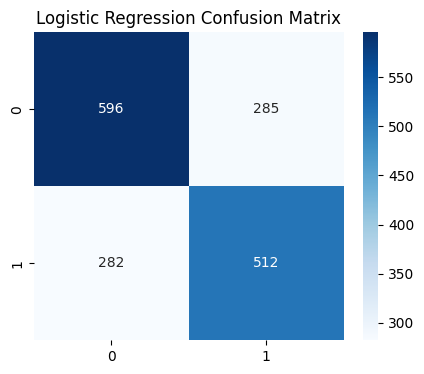


Decision Tree Accuracy: 0.6454

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.70      0.68       881
           1       0.64      0.58      0.61       794

    accuracy                           0.65      1675
   macro avg       0.64      0.64      0.64      1675
weighted avg       0.64      0.65      0.64      1675



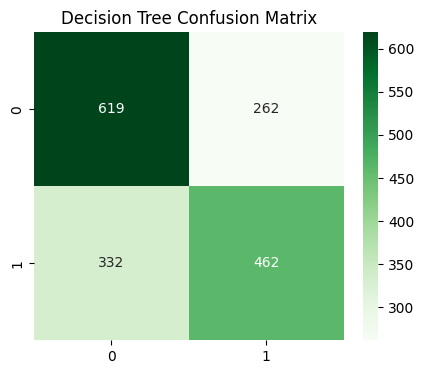

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

TabTransformer Accuracy: 0.7122

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       881
           1       0.74      0.61      0.67       794

    accuracy                           0.71      1675
   macro avg       0.72      0.71      0.71      1675
weighted avg       0.72      0.71      0.71      1675



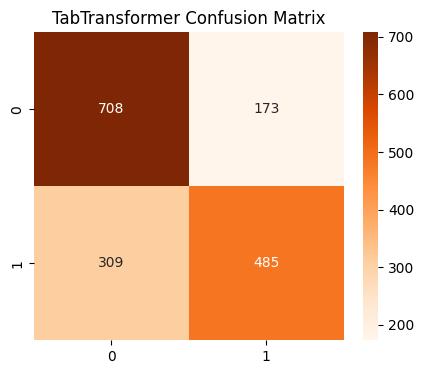

/tmp/ipython-input-2186538455.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accs, palette=['blue','green','orange'])


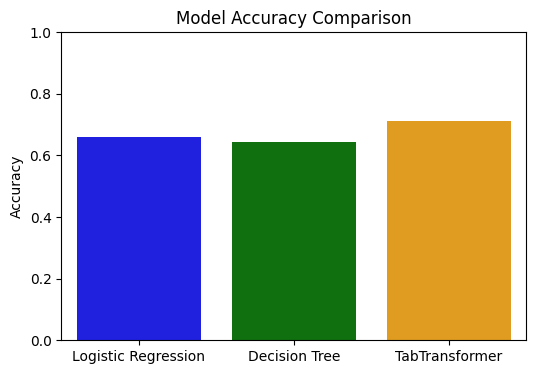

In [ ]:
# ============================
# Baseline Comparison: Logistic Regression, Decision Tree vs TabTransformer
# ============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train_b, y_train)
y_pred_log = log_model.predict(X_test_b)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# --- Decision Tree ---
tree_model = DecisionTreeClassifier(max_depth=None, min_samples_leaf=5, random_state=42)
tree_model.fit(X_train_b, y_train)
y_pred_tree = tree_model.predict(X_test_b)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f"\nDecision Tree Accuracy: {acc_tree:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

# --- TabTransformer Evaluation ---
y_pred_tab = (final_model.predict(test_inputs) > 0.5).astype(int).flatten()
acc_tab = accuracy_score(y_test, y_pred_tab)

print(f"\nTabTransformer Accuracy: {acc_tab:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tab))

cm_tab = confusion_matrix(y_test, y_pred_tab)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tab, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1], yticklabels=[0,1])
plt.title("TabTransformer Confusion Matrix")
plt.show()

# --- Accuracy Comparison Plot ---
plt.figure(figsize=(6,4))
models = ['Logistic Regression', 'Decision Tree', 'TabTransformer']
accs = [acc_log, acc_tree, acc_tab]
sns.barplot(x=models, y=accs, palette=['blue','green','orange'])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


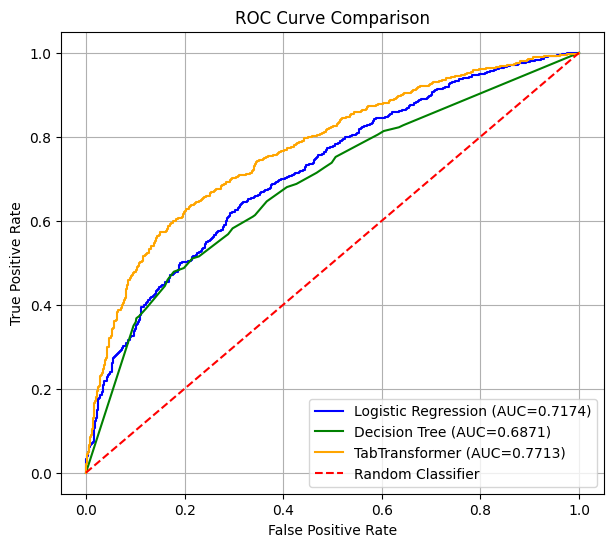

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- Calculating probabilities ---
y_prob_log = log_model.predict_proba(X_test_b)[:,1]
y_prob_tree = tree_model.predict_proba(X_test_b)[:,1]
y_prob_tab = final_model.predict(test_inputs).flatten()

# --- ROC Curves ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_tab, tpr_tab, _   = roc_curve(y_test, y_prob_tab)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_tab = roc_auc_score(y_test, y_prob_tab)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.4f})', color='blue')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={auc_tree:.4f})', color='green')
plt.plot(fpr_tab, tpr_tab, label=f'TabTransformer (AUC={auc_tab:.4f})', color='orange')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


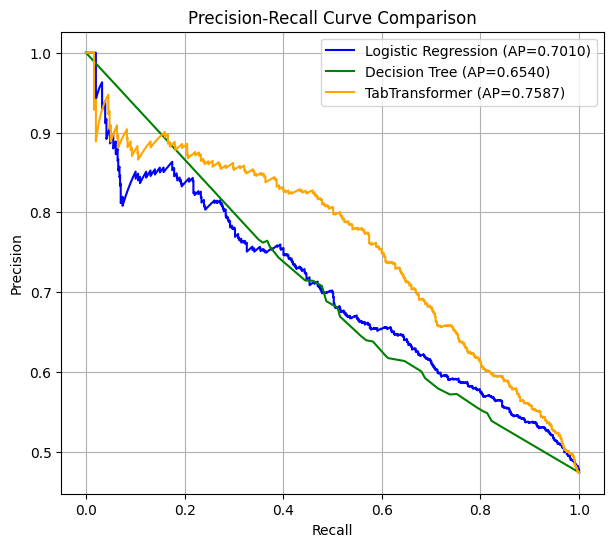

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- Calculating probabilities ---
y_prob_log = log_model.predict_proba(X_test_b)[:,1]
y_prob_tree = tree_model.predict_proba(X_test_b)[:,1]
y_prob_tab = final_model.predict(test_inputs).flatten()

# --- Precision-Recall Curves ---
prec_log, rec_log, _ = precision_recall_curve(y_test, y_prob_log)
prec_tree, rec_tree, _ = precision_recall_curve(y_test, y_prob_tree)
prec_tab, rec_tab, _   = precision_recall_curve(y_test, y_prob_tab)

# --- Average Precision (AP) For each model---
ap_log = average_precision_score(y_test, y_prob_log)
ap_tree = average_precision_score(y_test, y_prob_tree)
ap_tab = average_precision_score(y_test, y_prob_tab)

plt.figure(figsize=(7,6))
plt.plot(rec_log, prec_log, label=f'Logistic Regression (AP={ap_log:.4f})', color='blue')
plt.plot(rec_tree, prec_tree, label=f'Decision Tree (AP={ap_tree:.4f})', color='green')
plt.plot(rec_tab, prec_tab, label=f'TabTransformer (AP={ap_tab:.4f})', color='orange')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()
